In [1]:
import time
start_time = time.time()

In [2]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import json
import pandas as pd
import sys
from pathlib import Path
import os
import math


In [3]:
# Add path to py_modules 
sys.path.append(str(Path().resolve().parents[0] / 'py_modules')) # 1 level up = project root

# Add path to pipeline_config.py
sys.path.append(str(Path().resolve().parents[0]))  # 1 level up = project root

# Import from pipeline_config and py_modules
from pipeline_config import RESULTS_DIR, MAPS_DIR

In [4]:
data_all = [
    'H_I-6563_mask_0_bin_0',
    'O_III-5007_mask_0_bin_0',
    'N_II-6583_mask_0_bin_0',
    'S_III-9069_mask_0_bin_0',
    'Ar_III-7136_mask_0_bin_0'
]


# Custom labels dictionary
labels_dict = {
    'H_I-6563_mask_0_bin_0': r'H$\alpha$',
    'O_III-5007_mask_0_bin_0': r'[O III] $\lambda$5007',
    'N_II-6583_mask_0_bin_0': r'[N II] $\lambda$6583',
    'S_III-9069_mask_0_bin_0': r'[S III] $\lambda$9069',
    'Ar_III-7136_mask_0_bin_0': r'[Ar III] $\lambda$7136',

}

In [5]:
#raw_data

In [6]:
processed_data = {}
raw_data = {}

for name in data_all:
    with open(MAPS_DIR / f"{name}.json") as f:
        json_data = json.load(f)

    sb = np.array(json_data["sb"])
    vv = np.array(json_data["vv"])

    vv[sb == 0] = np.nan

    raw_data[name] = {
        "sb": sb,
        "vv": vv
    }

    # Create DataFrames
    sb_df = pd.DataFrame(sb).stack().reset_index().rename(columns={'level_0': 'X', 'level_1': 'Y', 0: 'SB'})
    vv_df = pd.DataFrame(vv).stack().reset_index().rename(columns={'level_0': 'X', 'level_1': 'Y', 0: 'VV'})

    # Merge the DataFrames
    df = vv_df.copy()
    df['SB'] = sb_df['SB']

    processed_data[name] = df


In [7]:
raw_data['H_I-6563_mask_0_bin_0']

{'sb': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]),
 'vv': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]])}

In [8]:
processed_data['H_I-6563_mask_0_bin_0'].describe()

,X,Y,VV,SB
count,2.555689e+06,2.555689e+06,2.555689e+06,2.555689e+06
mean,8.828562e+02,7.344378e+02,1.410055e+01,7.263067e-02
std,5.053856e+02,4.225088e+02,2.898363e+00,6.122515e-02
min,0.000000e+00,0.000000e+00,2.930000e+00,0.000000e+00
25%,4.450000e+02,3.690000e+02,1.219000e+01,3.000000e-02
50%,8.830000e+02,7.340000e+02,1.406000e+01,5.000000e-02
75%,1.321000e+03,1.100000e+03,1.604000e+01,1.000000e-01
max,1.764000e+03,1.474000e+03,2.522000e+01,8.900000e-01


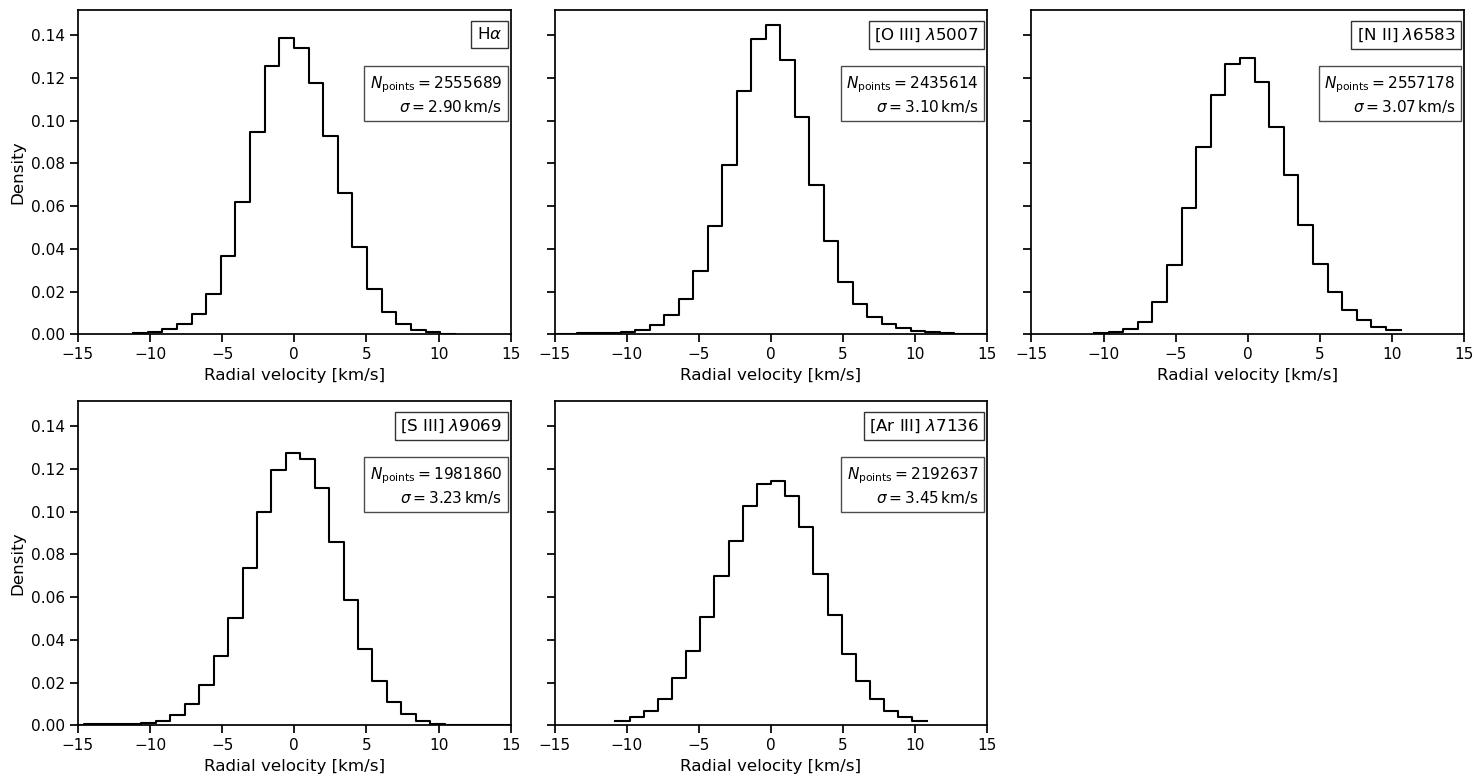

In [9]:
sns.set_context("notebook")


# Layout calculation
n_plots = len(data_all)
n_cols = 3 # Change for a wider grid
n_rows = math.ceil(n_plots / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
axes = axes.flatten()

# Loop through datasets
for ax, name in zip(axes, data_all):
    df = processed_data[name].copy()
    df['RV_centered'] = df['VV'] - df['VV'].mean()

    sns.histplot(
        data=df,
        x="RV_centered",
        binwidth=1,
        element="step",
        fill=False,
        color='k',
        stat='density',
        ax=ax
    )

    # Pretty label and stats
    label = labels_dict.get(name, name)
    ax.text(0.98, 0.95, label, transform=ax.transAxes,
            ha='right', va='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='k'))

    n_points = len(df)
    var_rv = df['RV_centered'].std()
    stats_text = f"$N_{{\\text{{points}}}} = {n_points}$\n$\\sigma = {var_rv:.2f}\\,\\mathrm{{km/s}}$"
    ax.text(0.98, 0.80, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=11, bbox=dict(facecolor='white', alpha=0.7))
    ax.set_xlim(-15,15)
    ax.set_xlabel("Radial velocity [km/s]")

# Remove unused axes if any
for i in range(n_plots, len(axes)):
    fig.delaxes(axes[i])

axes[0].set_ylabel("Density")
plt.tight_layout()
plt.savefig("pdfs.pdf", bbox_inches='tight')
plt.show()


C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_27300\2087161954.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right for cbar


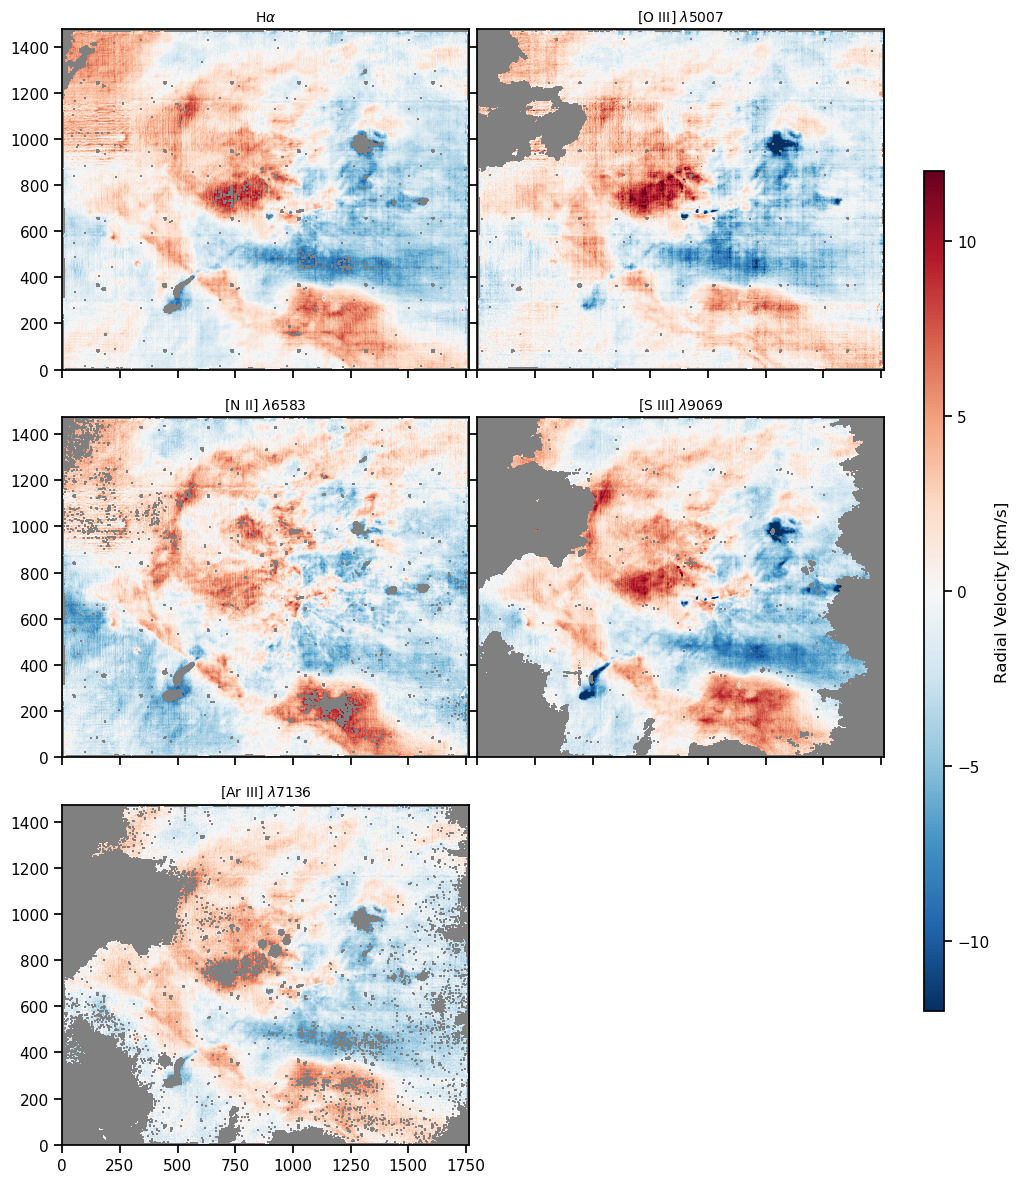

In [17]:
# Layout setup
n_plots = len(data_all)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()

# Loop through datasets
im = None
for ax, name in zip(axes, data_all):
    vv = raw_data[name]["vv"] - np.nanmean(raw_data[name]["vv"])

    im = ax.imshow(vv.T, cmap='RdBu_r', origin='lower', vmin=-10, vmax=10)
    ax.set_title(labels_dict.get(name, name), fontsize=10)
    
    # Set black background for NaNs
    im.cmap.set_bad(color='grey')
#    ax.invert_yaxis()


# Remove unused axes
for i in range(n_plots, len(axes)):
    fig.delaxes(axes[i])

# Add colorbar in a manually defined axis (position = [left, bottom, width, height])
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # adjust as needed
fig.colorbar(im, cax=cbar_ax).set_label("Radial Velocity [km/s]")
im.set_clim(-12, 12)


plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right for cbar
plt.savefig("velocity_maps_shared_cbar_fixed.png", bbox_inches='tight')
plt.show()
